In [30]:
# PyTorch
import torch                         # PyTorch main library (tensors, autograd, etc.).
import torch.nn as nn                # Neural networks (layers, loss functions, etc.).
import torch.nn.functional as F      # Activation functions and loss functions (opcional)
import torch.optim as optim          # Optimization (Adam, SGD, etc.)
from torch.utils.data import TensorDataset, DataLoader, random_split  # Dataset y DataLoaders

# Images and transformations
from PIL import Image                # Charge and manipulate images (PIL library).
from torchvision import transforms   # Transforming images to tensors (resize, crop, normalize, etc.).

# Visualisation 
import matplotlib.pyplot as plt     # Show images and plots.
import numpy as np                  # Arrays and numerical operations

# Utilities
import math                         # Math functions (pi, sin, cos)
from tqdm import tqdm               # Progress bar for training loops.

import os                           # Interaction with OS (file paths, directories).


# Práctica 1 - Ejercicio 2

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

Este es el segundo ejercicio de la Práctica 1 de Programación para la Inteligencia Artificial. Este ejercicio se debe entregar en un cuaderno de Jupyter separado del primero.

El objetivo es entrenar un modelo neuronal con capas lineales (MLP) para que aprenda esta imagen:
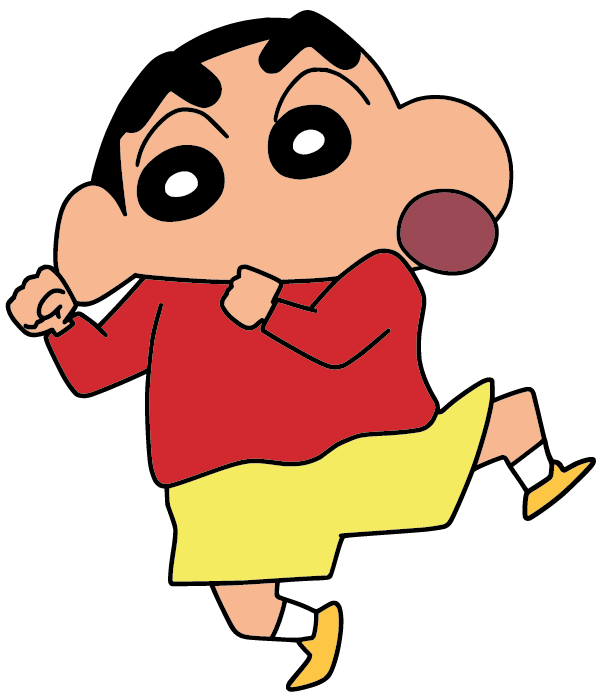

La imagen está disponible para ser descargada junto a este cuaderno (no hay que intentar extraerla del cuaderno). Para simplificar la práctica, la imagen se reducirá a un tamaño 35x30.

El modelo neuronal tiene que servir para reproducir la imagen sin necesidad de la propia imagen una vez entrenado. Se debe tener en cuenta que una imagen son colores asociados a una posición y crear un sistema en base a dicha relación.

Este problema tiene una dificultad asociada al comportamiento de los MLPs. Los MLPS son buenos aprendiendo funciones *suaves*. El problema es que una imagen es propensa a tener cambios bruscos. Por ejemplo, inmediatamente junto al color negro (\[0,0,0\] en RGB) puede ir el color blanco (\[255,255,255\] en RGB). Estas variaciones son denominamas variaciones de alta frecuencia y el MLP no es muy eficiente aprendiendo a representarlas. Para facilitar su aprendizaje podemos codificar la entrada del MLP usando una función como la siguiente que habitualmente denominamos codificación posicional (*positional encoding*):

$$\gamma(\mathbf{x})=[\gamma(x_{1}), \gamma(x_{2}),..,\gamma(x_{n})]$$ con $$\mathbf{x} \in [0,1]^n$$

$$\gamma(x_{i}) = [x_{i}, sin(2^{0}\pi x_{i}), cos(2^{0}\pi x_{i}), sin (2^{1}\pi x_{i}), cos(2^{1}\pi x_{i}),..., sin(2^{L-1}\pi x_{i}), cos(2^{L-1}\pi x_{i})]$$

Aquí está ya programado como un módulo de PyTorch :)

In [31]:
class Positional_Encoder(nn.Module):
    def __init__(self, L=10, include_input=True, device='cpu'):
        """
        Inicializa el codificador posicional.

        Args:
            L (int): Número de frecuencias a usar (controla el nivel de detalle).
            include_input (bool): Si se incluye o no el valor original x en la salida.
            device (str): Dispositivo ('cpu' o 'cuda').
        """
        super(Positional_Encoder, self).__init__()
        self.include_input = include_input
        self.device = device

        # Creamos las bandas de frecuencia: [1, 2, 4, 8, ..., 2^(L-1)]
        # Estas se usarán para escalar las coordenadas antes de aplicar sin() y cos()
        self.freq_bands = 2. ** torch.linspace(0., L - 1, L, device=self.device)

    def forward(self, x):
        """
        Aplica la codificación posicional a las coordenadas de entrada.

        Args:
            x (tensor): Tensor de forma (..., dims), por ejemplo (N,2) para coordenadas 2D.

        Returns:
            Tensor codificado que contiene las versiones seno y coseno de las coordenadas
            en distintas frecuencias.
        """

        # Si include_input=True, empezamos la salida incluyendo el propio x original
        out = [x] if self.include_input else []

        # Para cada frecuencia en freq_bands, aplicamos las funciones seno y coseno
        for freq in self.freq_bands:
            out.append(torch.sin(freq * x * math.pi))  # componente seno
            out.append(torch.cos(freq * x * math.pi))  # componente coseno

        # Concatenamos todas las representaciones a lo largo de la última dimensión
        # Si x es (N,2) y L=10, la salida será (N, 2 + 2*2*10) = (N, 42)
        return torch.cat(out, dim=-1)

    def get_output_dim(self, input_dim):
        """
        Calcula cuántas dimensiones tendrá el vector de salida del codificador
        en función del número de frecuencias L y si se incluye la entrada original.
        """
        # Si include_input=True:
        #   salida = input_dim + 2 * input_dim * L
        # Si include_input=False:
        #   salida = 2 * input_dim * L
        return input_dim + 2 * input_dim * self.freq_bands.shape[0]


Recomiendo usarlo con los valores por defecto (L=10, include_input=True).

Intuitivamente la codificación posicional descompone los valores de entrada a una representación de la misma información en diversas frecuencias permitiendo que distintas entradas del MLP atiendan a distintos niveles de detalle.

Una vez entrenado el MLP. se requiere usarlo para generar la imagen al doble de resolución (70x60).

El cuaderno debe entregarse con los experimentos que se consideren más relevantes para resolver el problema.

El cuaderno entregado debe llamarse ApellidosNombrePractica1Ejercicio2.ipynb

Consejos:

*   Normalizar los colores de la imagen al rango [0,1].
*   Empezar trabajando con una resolución más pequeña o en escala de grises para simplificar el problema.

In [32]:
# Charge the image and convert to RGB format.
image_original = Image.open("C:/Users/danir/Documents/Universidad/4Informatica/PIA/practicas/shin_chan_progIA.png").convert("RGB")  

# Dimensions of the input coordinates (x, y) for the positional encoder.
width, height = 35, 30

# Resize the image to (width=35, height=30).
image_resized = image_original.resize((width, height))  

# Create a grid of (x, y) coordinates normalized to [0, 1].
x = torch.linspace(0, 1, steps = width)
y = torch.linspace(0, 1, steps = height)
grid_y, grid_x = torch.meshgrid(y, x, indexing = 'ij')

# Stack the grid coordinates into a tensor of shape (height*width, 2).
coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

# Convert the resized image to a tensor.
image_tensor = transforms.ToTensor()(image_resized)  

# Reshape to (height*width, 3).
colors = image_tensor.permute(1, 2, 0).reshape(-1, 3)  

# Create a TensorDataset and DataLoader from the colors tensor.
dataset = TensorDataset(coordinates, colors)  
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)  

In [33]:
class ImageMLP (nn.Module):
    def __init__(self):
        super().__init__()

        # Define the positional encoder with L=10 and include_input=True.
        self.encoder = Positional_Encoder(L=10, include_input=True)

        # Calculate the input dimension after encoding (x, y) using the positional encoder.
        dim_input = self.encoder.get_output_dim(input_dim=2)  # Input dimension after encoding (x, y).

        # Define the MLP architecture.
        self.fc1 = nn.Linear(dim_input, 256)   # First fully connected layer.
        self.fc2 = nn.Linear(256, 256)         # Second fully connected layer
        self.fc3 = nn.Linear(256, 256)         # Third fully connected layer.
        self.fc4 = nn.Linear(256, 3)           # Output layer (RGB values).

    def forward(self, x):
        x = self.encoder(x)  # Apply positional encoding to the input coordinates.

        x = F.relu(self.fc1(x))  # Apply ReLU activation after the first layer.
        x = F.relu(self.fc2(x))  # Apply ReLU activation after the second
        x = F.relu(self.fc3(x))  # Apply ReLU activation after the third layer.

        x = torch.sigmoid(self.fc4(x))  # Apply sigmoid activation to the output layer to get RGB values in [0, 1].

        return x

# Create an instance of the ImageMLP model and move it to the appropriate device (CPU or GPU).
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")  # Forcing to use CPU for this example.
model = ImageMLP().to(device)

Training MLP: 100%|██████████| 10000/10000 [13:04<00:00, 12.74it/s, Loss=0.001853] 


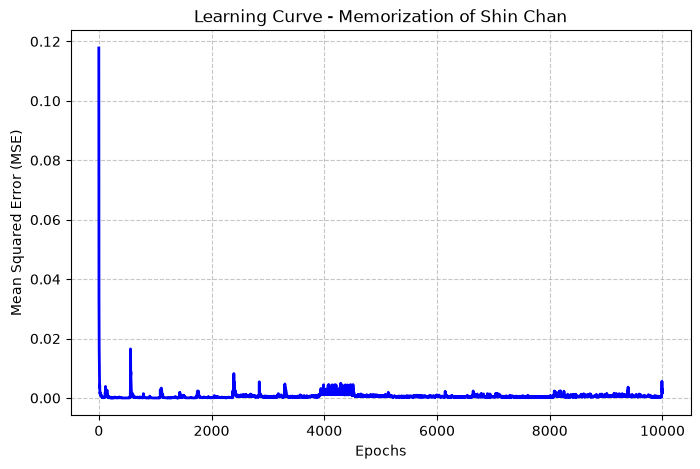

In [34]:
loss_function = nn.MSELoss()  # Mean Squared Error loss for regression tasks (RGB values).
optimizer = optim.Adam(model.parameters(), lr=1e-2)  # Adam optimizer with learning rate of 0.01.

# Number of training steps (iterations) for the model.
steps = 10000 

history_loss = []  # To store the loss values for plotting later.

# Create a progress bar using tqdm to visualize the training process.
progress_bar = tqdm(range(steps), desc="Training MLP")

# Training loop
for epoch in progress_bar:
    epoch_loss = 0.0  # Initialize the loss for the current epoch.

    # Iterate over the DataLoader to get batches of coordinates and colors.
    for batch_coords, batch_colors in dataloader:
        batch_coords, batch_colors = batch_coords.to(device), batch_colors.to(device)  # Move data to the appropriate device.

        optimizer.zero_grad()  # Zero the gradients before backpropagation.

        predicted_colors = model(batch_coords)  # Forward pass: predict colors from coordinates.

        loss = loss_function(predicted_colors, batch_colors)  # Compute the loss between predicted and true colors.

        loss.backward()  # Backpropagation: compute gradients.

        optimizer.step()  # Update model parameters based on gradients.

        epoch_loss += loss.item() # Accumulate the loss for the current epoch.

    loss_mean = epoch_loss / len(dataloader)  # Calculate the mean loss for the epoch.
    history_loss.append(loss_mean)  # Store the mean loss for plotting later.
    
    # Update the progress bar with the current loss every 10 epochs.
    if (epoch + 1) % 10 == 0: 
        progress_bar.set_postfix({'Loss': f'{loss.item():.6f}'})

# Draw the learning curve at the end of training.
plt.figure(figsize=(8, 5))
plt.plot(history_loss, color='blue', linewidth=2)
plt.title('Learning Curve - Memorization of Shin Chan')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

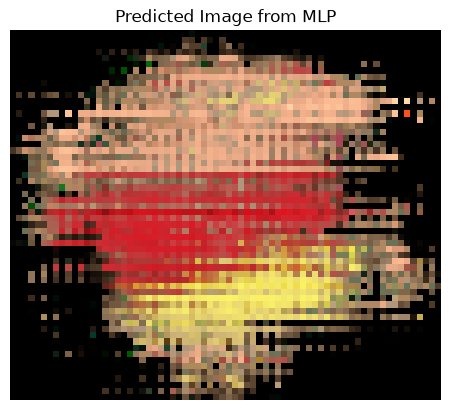

In [35]:
with torch.no_grad():  # Disable gradient computation for evaluation.
    # Create a new grid of (x, y) coordinates for evaluation, normalized to [0, 1].
    x_new = torch.linspace(0, 1, steps = 70)
    y_new = torch.linspace(0, 1, steps = 60)
    gy, gx = torch.meshgrid(y_new, x_new, indexing = 'ij')

    coordinates_new = torch.stack([gx.flatten(), gy.flatten()], dim=1).to(device)  # Stack the new grid coordinates.

    colors_predicted = model(coordinates_new)  # Predict colors for the new coordinates.

image_final = colors_predicted.reshape(60, 70, 3).cpu().numpy()  # Reshape the predicted colors to (60, 70, 3) and convert to numpy.

plt.imshow(image_final)  # Display the predicted image.
plt.axis('off')  # Turn off axis labels.
plt.title("Predicted Image from MLP")  # Set the title of the plot.
plt.show()  # Show the plot.

Durante el desarrollo de esta práctica he comprobado que entrenar una red neuronal para que memorice una imagen a partir de sus coordenadas no funciona igual que los clasificadores tradicionales. Al principio intenté aplicar la división clásica de conjuntos de entrenamiento y test, pero me di cuenta de que si ocultas trozos del propio Shin Chan, la red genera huecos y parches porque no puede adivinar lo que no ha visto.

Aquí el truco está en entender que la red no busca generalizar ante imágenes nuevas, sino hacer un overfitting controlado del 100% de los píxeles utilizando el codificador posicional para capturar los detalles finos. La verdadera prueba de que el modelo funciona no es evaluar un conjunto de test aleatorio, sino el proceso de upscaling, donde le pides coordenadas intermedias que no existían y es capaz de interpolarlas para sacar una imagen más grande y nítida. Con la curva de aprendizaje veo claramente cómo el error baja hasta estabilizarse, confirmando que la red ha interiorizado por completo la función matemática de la imagen.